3.1 Precipation data

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as colors
import seaborn as sns

# Exploration of the data's encoding:
!curl -s "https://opendata.dwd.de/climate_environment/CDC/helprr_wetter_tageswerte_Beschreibung_Stationen.txt" | file -

/dev/stdin: ISO-8859 text, with very long lines (1000), with CRLF line terminators


In [18]:
# 1.1 DATA CLEANING

# Downloading the data, converting it to utf-8, and removing carriage return characters for proper handling of DOS Format:
!curl -s "https://opendata.dwd.de/climate_environment/CDC/helprr_wetter_tageswerte_Beschreibung_Stationen.txt" | iconv -f iso-8859-1 -t utf-8 | tr -d '\r' > stations.txt

STATES = ['Baden-Württemberg', 'Bayern', 'Berlin', 'Bremen', 'Hamburg', 'Hessen', 'Mecklenburg-Vorpommern', 'Niedersachsen', 'Nordrhein-Westfalen', 'Rheinland-Pfalz', 'Saarland', 'Sachsen', 'Sachsen-Anhalt', 'Schleswig-Holstein', 'Thüringen']

# Converting .txt file to Pandas DataFrame for easier manipulation:
rows = []
with open('stations.txt', encoding='utf-8') as stations_f:
    for line in stations_f:
        line = line.strip()
        parts = line.split(None, 6)     # Splitting numerical entries by whitespace.
        if len(parts) > 6:
            remaining = parts[6]
            # Finding the earliest occurrence of any state name in the remaining text:
            seventh_idx = -1
            for marker in STATES:
                idx = remaining.find(marker)
                if idx != -1 and (seventh_idx == -1 or idx < seventh_idx):
                    seventh_idx = idx
            # Splitting sixth from seventh column:
            if seventh_idx != -1:
                parts[6] = remaining[:seventh_idx].strip()
                state_text = remaining[seventh_idx:].strip()
                # Cleaning last column to contain nothing but state names:
                for state in STATES:
                    if state_text.startswith(state):
                        parts.append(state)
                        break
        rows.append(parts)
stations_df = pd.DataFrame(rows).set_index(0)   # Setting index.

# Adjusting header:
stations_df.columns = stations_df.iloc[0]
stations_df = stations_df.iloc[2:]
stations_df.columns.values[-1] = 'Bundesland'
stations_df.columns.values[-2] = 'Stationsname'

# Converting numerical columns to appropriate data types:
stations_df = stations_df.astype({
    stations_df.columns[0]: 'Int64',
    stations_df.columns[1]: 'Int64',
    stations_df.columns[2]: 'Int64',
    stations_df.columns[3]: 'Int64',
    'geoBreite': 'float64',
    'geoLaenge': 'float64'
})

# Converting Pandas DataFrame to .csv file:
stations_df.to_csv('stations.csv', index=False)

# Exploration of elevation data:
print(stations_df['Stationshoehe'].describe())

count        5311.0
mean     288.349275
std      239.154753
min            -1.0
25%            80.0
50%           252.0
75%           437.0
max          2956.0
Name: Stationshoehe, dtype: Float64


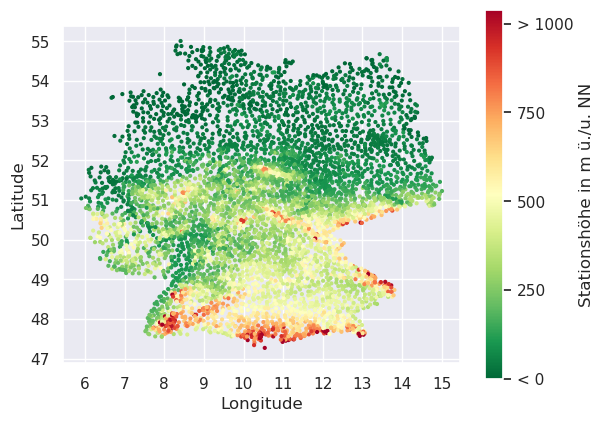

In [20]:
# 1.2 PLOT

# Based on the description above it seems sensible to exclude some of the highest stations from the colormapping process to prevent them from dominating the color range as most stations are located at rather low elevations. We choose to mark the 0.5% highest stations as "outliers".

# Excluding outliers from colormapping norm:
elevations = stations_df['Stationshoehe'].to_numpy()
outliers = np.argsort(elevations)[-int(len(elevations)/200):]
elev_wo_outliers = np.delete(elevations, outliers)
norm = colors.Normalize(vmin=np.min(elev_wo_outliers), vmax=np.max(elev_wo_outliers))

# Plot:
sns.set_theme()
fig, ax = plt.subplots()
# Choosing a reversed red-green colormap because this is common for relief maps.
sc = ax.scatter(stations_df['geoLaenge'], stations_df['geoBreite'], s=4, c=elevations, cmap='RdYlGn_r', norm=norm)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Displaying the map equidistantly as we are lacking an actual projected coordinate system:
ax.set_aspect('equal')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
cbar = fig.colorbar(sc, ax=ax, label='Stationshöhe in m ü./u. NN')
cbar.set_ticks(np.linspace(0, 1000, 5))
cbar.set_ticklabels(['< 0', '250', '500', '750','> 1000'])
plt.show()